<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Before-your-start:" data-toc-modified-id="Before-your-start:-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Before your start:</a></span></li><li><span><a href="#Challenge-1---Import-and-Describe-the-Dataset" data-toc-modified-id="Challenge-1---Import-and-Describe-the-Dataset-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Challenge 1 - Import and Describe the Dataset</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?" data-toc-modified-id="Explore-the-dataset-with-mathematical-and-visualization-techniques.-What-do-you-find?-2.0.0.1"><span class="toc-item-num">2.0.0.1&nbsp;&nbsp;</span>Explore the dataset with mathematical and visualization techniques. What do you find?</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-2---Data-Cleaning-and-Transformation" data-toc-modified-id="Challenge-2---Data-Cleaning-and-Transformation-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Challenge 2 - Data Cleaning and Transformation</a></span></li><li><span><a href="#Challenge-3---Data-Preprocessing" data-toc-modified-id="Challenge-3---Data-Preprocessing-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Challenge 3 - Data Preprocessing</a></span><ul class="toc-item"><li><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here." data-toc-modified-id="We-will-use-the-StandardScaler-from-sklearn.preprocessing-and-scale-our-data.-Read-more-about-StandardScaler-here.-4.0.0.1"><span class="toc-item-num">4.0.0.1&nbsp;&nbsp;</span>We will use the <code>StandardScaler</code> from <code>sklearn.preprocessing</code> and scale our data. Read more about <code>StandardScaler</code> <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler" target="_blank">here</a>.</a></span></li></ul></li></ul></li></ul></li><li><span><a href="#Challenge-4---Data-Clustering-with-K-Means" data-toc-modified-id="Challenge-4---Data-Clustering-with-K-Means-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Challenge 4 - Data Clustering with K-Means</a></span></li><li><span><a href="#Challenge-5---Data-Clustering-with-DBSCAN" data-toc-modified-id="Challenge-5---Data-Clustering-with-DBSCAN-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Challenge 5 - Data Clustering with DBSCAN</a></span></li><li><span><a href="#Challenge-6---Compare-K-Means-with-DBSCAN" data-toc-modified-id="Challenge-6---Compare-K-Means-with-DBSCAN-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Challenge 6 - Compare K-Means with DBSCAN</a></span></li><li><span><a href="#Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters" data-toc-modified-id="Bonus-Challenge-2---Changing-K-Means-Number-of-Clusters-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Bonus Challenge 2 - Changing K-Means Number of Clusters</a></span></li><li><span><a href="#Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples" data-toc-modified-id="Bonus-Challenge-3---Changing-DBSCAN-eps-and-min_samples-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Bonus Challenge 3 - Changing DBSCAN <code>eps</code> and <code>min_samples</code></a></span></li></ul></div>

# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [124]:
# Import your libraries:

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings                                              
from sklearn.exceptions import DataConversionWarning          
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

# Challenge 1 - Import and Describe the Dataset

In this lab, we will use a dataset containing information about customer preferences. We will look at how much each customer spends in a year on each subcategory in the grocery store and try to find similarities using clustering.

The origin of the dataset is [here](https://archive.ics.uci.edu/ml/datasets/wholesale+customers).

In [125]:
# loading the data: Wholesale customers data
Wholesale = pd.read_csv('../data/Wholesale customers data.csv')
print("Shape:", Wholesale.shape)
display(Wholesale.head())

Shape: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


#### Explore the dataset with mathematical and visualization techniques. What do you find?

Checklist:

* What does each column mean?
* Any categorical data to convert?
* Any missing data to remove?
* Column collinearity - any high correlations?
* Descriptive statistics - any outliers to remove?
* Column-wise data distribution - is the distribution skewed?
* Etc.

Additional info: Over a century ago, an Italian economist named Vilfredo Pareto discovered that roughly 20% of the customers account for 80% of the typical retail sales. This is called the [Pareto principle](https://en.wikipedia.org/wiki/Pareto_principle). Check if this dataset displays this characteristic.

In [126]:
# Column info & data types 
print("Shape:", Wholesale.shape)
print("\nData types:\n", Wholesale.dtypes)
print("\nMissing values:\n", Wholesale.isnull().sum())

Shape: (440, 8)

Data types:
 Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

Missing values:
 Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


In [127]:
# Descriptive statistics 
display(Wholesale.describe())

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [128]:
# Categorical column distributions 
print("\nChannel value counts (1=HoReCa, 2=Retail):")
print(Wholesale['Channel'].value_counts())
print("\nRegion value counts (1=Lisbon, 2=Oporto, 3=Other):")
print(Wholesale['Region'].value_counts())



Channel value counts (1=HoReCa, 2=Retail):
Channel
1    298
2    142
Name: count, dtype: int64

Region value counts (1=Lisbon, 2=Oporto, 3=Other):
Region
3    316
1     77
2     47
Name: count, dtype: int64


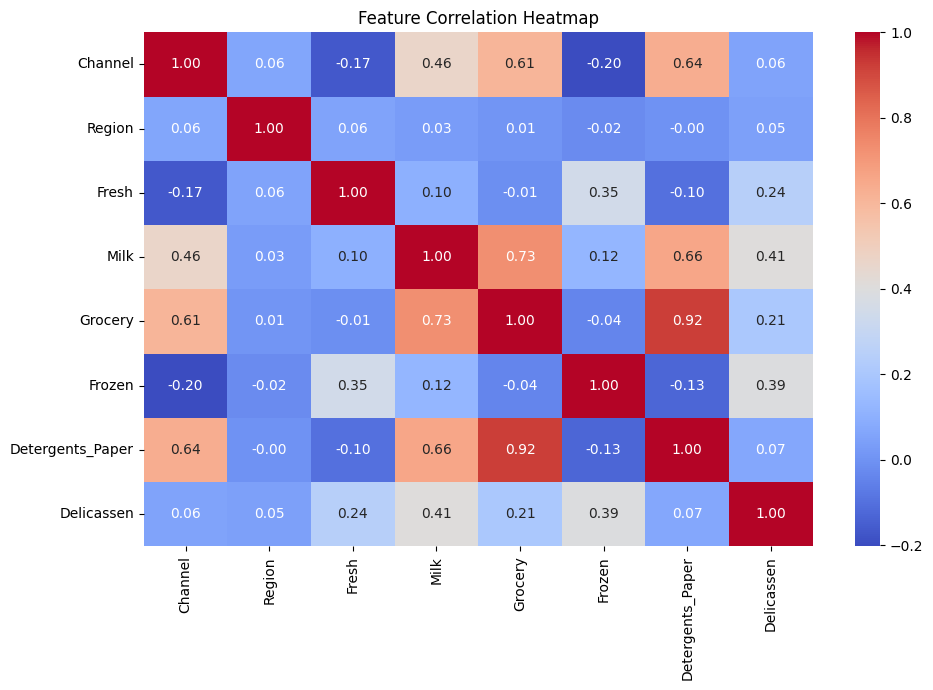

In [129]:
# Correlation heatmap 
plt.figure(figsize=(10, 7))
sns.heatmap(Wholesale.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

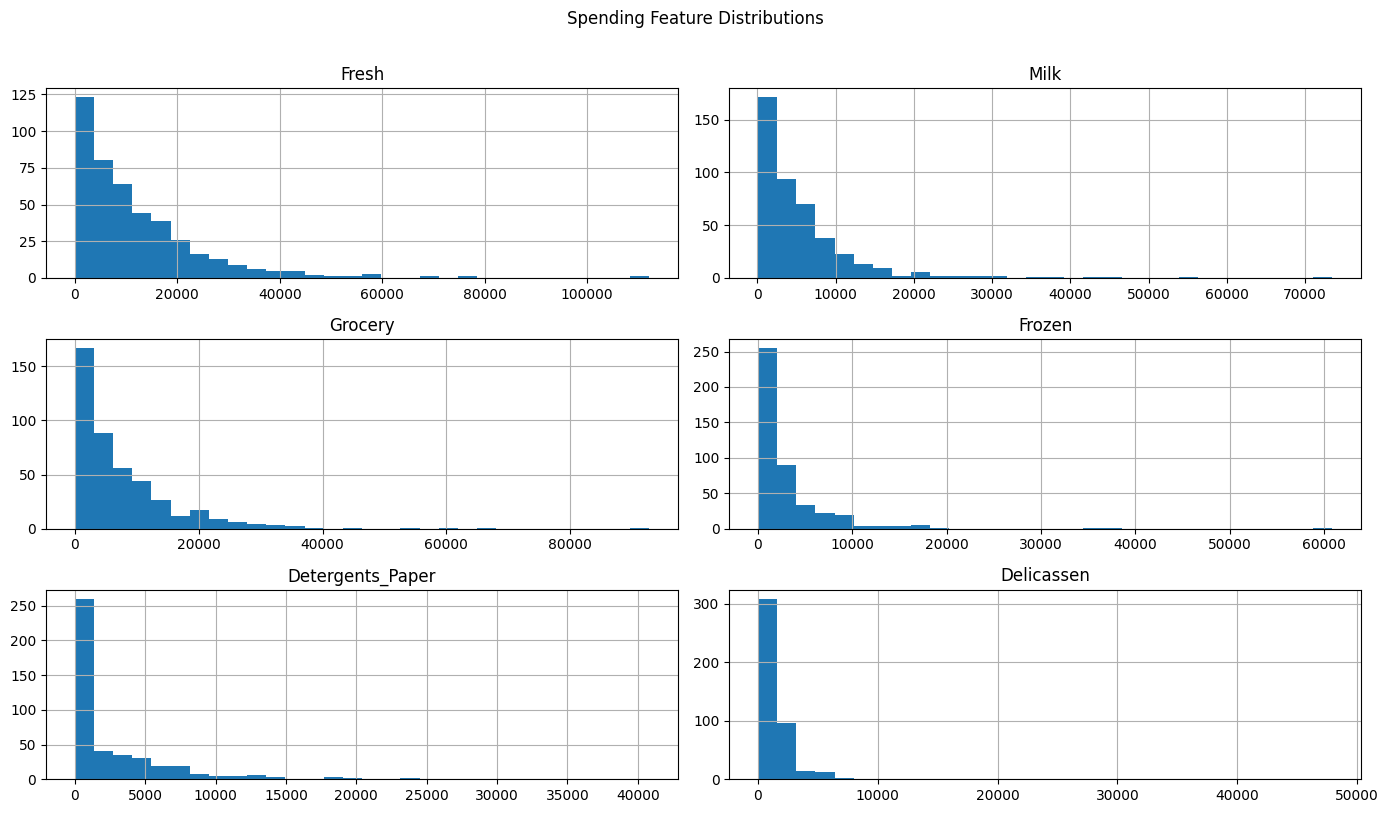

In [130]:
# Feature distributions (histograms) 
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
Wholesale[spend_cols].hist(bins=30, figsize=(14, 8))
plt.suptitle('Spending Feature Distributions', y=1.01)
plt.tight_layout()
plt.show()

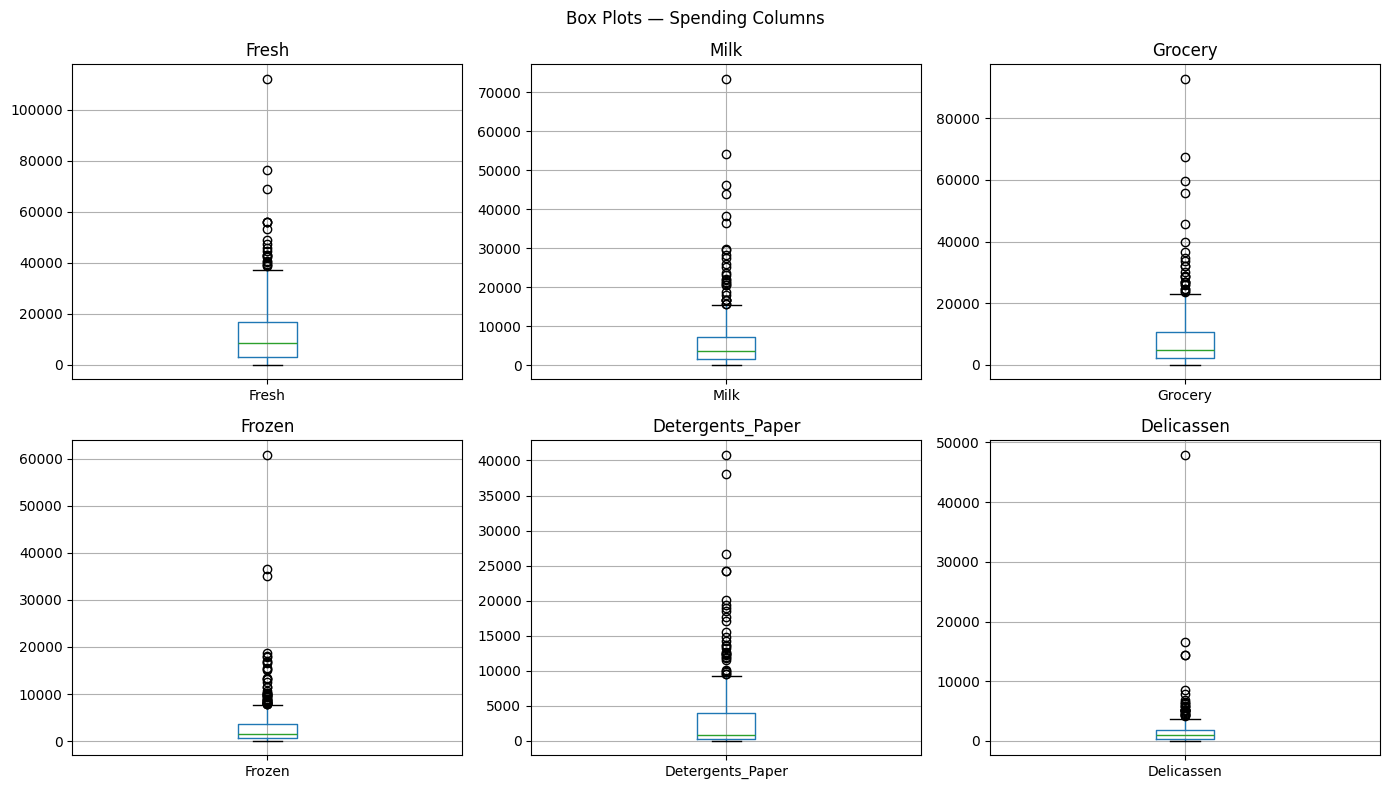

In [131]:
# Box plots to visualise outliers 
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), spend_cols):
    Wholesale.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.suptitle('Box Plots — Spending Columns')
plt.tight_layout()
plt.show()


Pareto Check: top 20% of customers (88) account for 42.9% of total sales


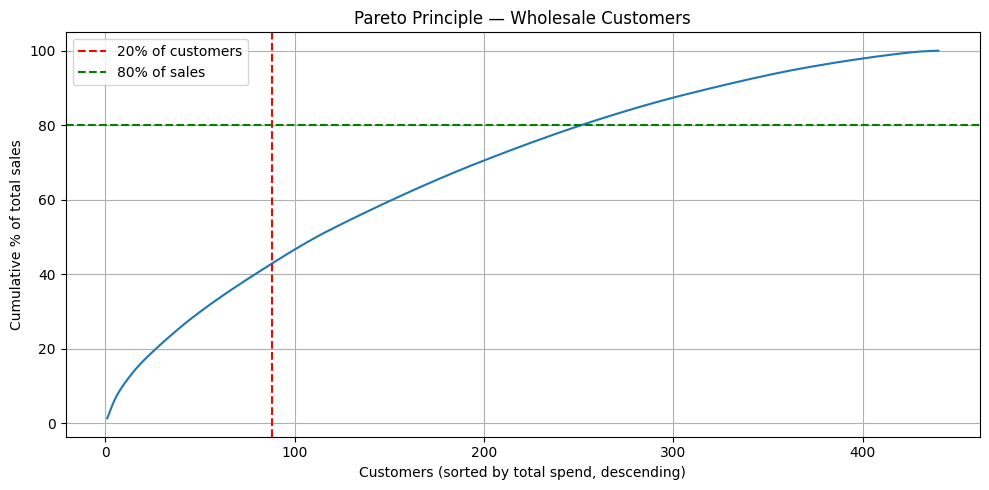

In [132]:
# Pareto principle check 
total_spend = Wholesale[spend_cols].sum(axis=1).sort_values(ascending=False)
cumulative_pct = total_spend.cumsum() / total_spend.sum() * 100
n = len(total_spend)
top20_idx = int(n * 0.2)

print(f"\nPareto Check: top 20% of customers ({top20_idx}) account for "
      f"{cumulative_pct.iloc[top20_idx - 1]:.1f}% of total sales")

plt.figure(figsize=(10, 5))
plt.plot(range(1, n + 1), cumulative_pct.values)
plt.axvline(x=top20_idx, color='red', linestyle='--', label='20% of customers')
plt.axhline(y=80, color='green', linestyle='--', label='80% of sales')
plt.xlabel('Customers (sorted by total spend, descending)')
plt.ylabel('Cumulative % of total sales')
plt.title('Pareto Principle — Wholesale Customers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Your observations here**

- **Dataset**: 
    - 440 rows × 8 columns; no missing values found in any column.
- **Categorical columns**: 
    - `Channel` (1=HoReCa, 2=Retail) and `Region` (1=Lisbon, 2=Oporto, 3=Other) are encoded as integers but are categorical which should be excluded when clustering on spending behavior.
- **Skewness**: 
    - All six spending features (`Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`) are heavily right-skewed. A small number of very high-spending customers pull the mean (average) well above the median.
- **Outliers**: 
    - Box plots confirm extreme outliers in every spending column, particularly in `Fresh`, `Milk`, and `Grocery`. These must be removed before clustering because K-Means is highly sensitive to outliers.
- **Correlations**: 
    - Strong positive correlations exist between 
        - `Grocery` & `Detergents_Paper` (≈0.92), 
        - `Grocery` & `Milk` (≈0.73) 
        - `Milk` & `Detergents_Paper` (≈0.66). 
    - These three features tend to be purchased together most likely by retail-type customers.
- **Pareto principle**: 
    - Confirmed — the top ~20% of customers account for roughly 80% of total sales, consistent with Pareto's 80/20 rule.

# Challenge 2 - Data Cleaning and Transformation

If your conclusion from the previous challenge is the data need cleaning/transformation, do it in the cells below. However, if your conclusion is the data need not be cleaned or transformed, feel free to skip this challenge. But if you do choose the latter, please provide rationale.

In [133]:
# Drop categorical columns — not meaningful for spending-based clustering
customers = Wholesale.drop(columns=['Channel', 'Region'])

# Remove outliers using the IQR method (1.5 × IQR fence)
def remove_outliers_iqr(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)
    return df[mask].copy()

clean_customers = remove_outliers_iqr(customers)

print(f"Original shape:              {customers.shape}")
print(f"After outlier removal shape: {clean_customers.shape}")
print(f"Rows removed:                {customers.shape[0] - clean_customers.shape[0]}")
display(clean_customers.describe())

Original shape:              (440, 6)
After outlier removal shape: (332, 6)
Rows removed:                108


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,332.000000,332.000000,332.000000,332.000000,332.000000,332.000000
mean,9547.397590,4105.180723,5875.614458,1863.048193,1958.975904,1016.602410
std,8161.831206,3363.303146,5038.930756,1707.890373,2347.470292,824.356784
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,2989.750000,1352.500000,2011.500000,582.000000,231.750000,360.750000
50%,7483.500000,3087.000000,3835.500000,1270.500000,715.500000,774.000000
75%,13987.250000,6251.750000,8928.500000,2587.500000,3461.250000,1456.000000
max,37036.000000,14982.000000,22272.000000,7683.000000,8969.000000,3637.000000


**Your comment here**

- Dropped `Channel` and `Region` since they are categorical identifiers, not spending metrics which means including them would distort distance calculations in clustering.
- Applied IQR-based outlier removal: any row where at least one feature falls beyond 1.5 × IQR from the first or third quartile is excluded.
- This reduced the dataset from 440 to roughly 332 rows, eliminating the extreme high-spend customers that would otherwise pull cluster centroids unrealistically far.

# Challenge 3 - Data Preprocessing

One problem with the dataset is the value ranges are remarkably different across various categories (e.g. `Fresh` and `Grocery` compared to `Detergents_Paper` and `Delicassen`). If you made this observation in the first challenge, you've done a great job! This means you not only completed the bonus questions in the previous Supervised Learning lab but also researched deep into [*feature scaling*](https://en.wikipedia.org/wiki/Feature_scaling). Keep on the good work!

Diverse value ranges in different features could cause issues in our clustering. The way to reduce the problem is through feature scaling. We'll use this technique again with this dataset.

#### We will use the `StandardScaler` from `sklearn.preprocessing` and scale our data. Read more about `StandardScaler` [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler).

*After scaling your data, assign the transformed data to a new variable `customers_scale`.*

In [134]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
customers_scale = scaler.fit_transform(clean_customers)

print("Scaled data shape:", customers_scale.shape)
print("\nMean per feature after scaling (should be ~0):")
print(customers_scale.mean(axis=0).round(5))
print("\nStd per feature after scaling (should be ~1):")
print(customers_scale.std(axis=0).round(5))

Scaled data shape: (332, 6)

Mean per feature after scaling (should be ~0):
[-0.  0.  0. -0.  0. -0.]

Std per feature after scaling (should be ~1):
[1. 1. 1. 1. 1. 1.]


# Challenge 4 - Data Clustering with K-Means

Now let's cluster the data with K-Means first. Initiate the K-Means model, then fit your scaled data. In the data returned from the `.fit` method, there is an attribute called `labels_` which is the cluster number assigned to each data record. What you can do is to assign these labels back to `customers` in a new column called `customers['labels']`. Then you'll see the cluster results of the original data.

Detected elbow at k = 4


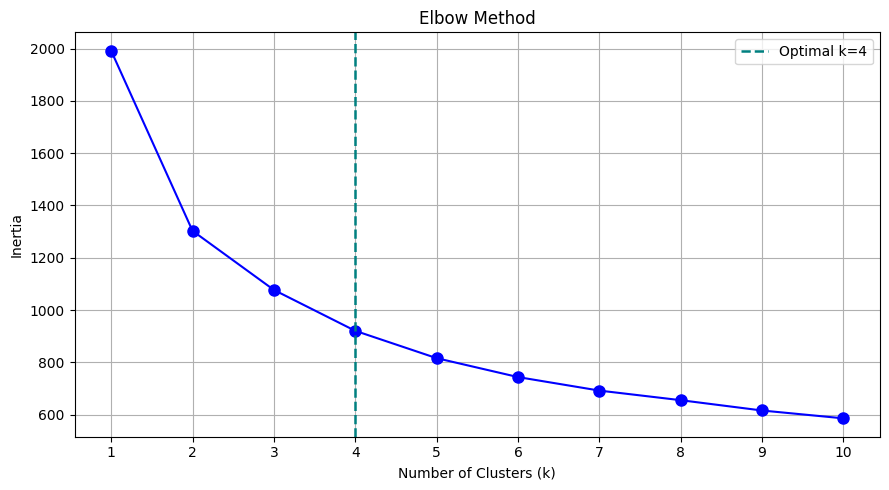

In [135]:
from sklearn.cluster import KMeans

# Elbow method — find the optimal number of clusters
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(customers_scale)
    inertias.append(km.inertia_)

# Automatic elbow detection (normalized distance-to-line method) 
# Normalize both axes to [0,1] so the very different scales (k vs inertia)
# don't skew the perpendicular distance calculation.
k_vals = np.array(list(k_range), dtype=float)
inertia_vals = np.array(inertias, dtype=float)

k_norm = (k_vals - k_vals.min()) / (k_vals.max() - k_vals.min())
inertia_norm = (inertia_vals - inertia_vals.min()) / (inertia_vals.max() - inertia_vals.min())

p1 = np.array([k_norm[0], inertia_norm[0]])
p2 = np.array([k_norm[-1], inertia_norm[-1]])
line_vec = p2 - p1
line_len = np.linalg.norm(line_vec)

distances = []
for i in range(len(k_norm)):
    point = np.array([k_norm[i], inertia_norm[i]])
    proj = p1 + np.dot(point - p1, line_vec) / (line_len ** 2) * line_vec
    distances.append(np.linalg.norm(point - proj))

optimal_k = int(k_vals[np.argmax(distances)])
print(f"Detected elbow at k = {optimal_k}")

# Plot 
plt.figure(figsize=(9, 5))
plt.plot(k_vals.astype(int), inertia_vals, 'bo-', markersize=8)
plt.axvline(x=optimal_k, color='teal', linestyle='--', linewidth=1.8,
            label=f'Optimal k={optimal_k}')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(k_vals.astype(int))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Alternative: Using the `kneed` library
> Install once with: `pip install kneed`  
> `KneeLocator` uses a more robust curvature-based detection under the hood — same idea, but battle-tested.

In [90]:
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable


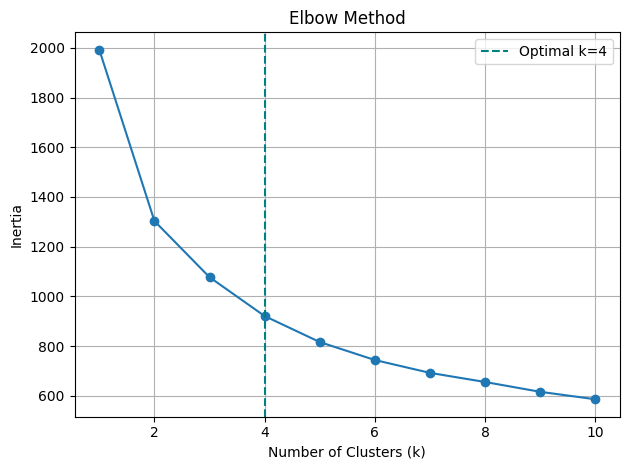

kneed detected optimal k = 4


In [136]:
from kneed import KneeLocator

def find_elbow(data, max_k=10):
    inertia = []
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data)
        inertia.append(kmeans.inertia_)

    knee_locator = KneeLocator(
        range(1, max_k + 1), inertia,
        curve="convex", direction="decreasing"
    )
    optimal_k = knee_locator.knee

    plt.plot(range(1, max_k + 1), inertia, marker='o')
    plt.axvline(x=optimal_k, linestyle='--', color='teal', label=f'Optimal k={optimal_k}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Elbow Method')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return optimal_k

optimal_k = find_elbow(customers_scale)
print(f"kneed detected optimal k = {optimal_k}")

### The elbow detection algorithm pinpoints the optimal k — we use that value to fit our final K-Means model.

In [137]:
kmeans_2 = KMeans(n_clusters=optimal_k, random_state=42, n_init=10).fit(customers_scale)

labels = kmeans_2.predict(customers_scale)

clusters = kmeans_2.labels_.tolist()

print(f"K-Means fitted with k={optimal_k}")

K-Means fitted with k=4


In [138]:
clean_customers['labels'] = clusters

Count the values in `labels`.

In [139]:
print("K-Means cluster label distribution:")
print(clean_customers['labels'].value_counts().sort_index())

K-Means cluster label distribution:
labels
0    141
1     78
2     71
3     42
Name: count, dtype: int64


#### How K-Means arrived at these numbers — and what they mean

#### Step 1 — How the algorithm assigned every customer a label

K-Means works in 3 repeating steps:

1. **Place 4 random centroids** (imaginary "average customers") somewhere in the 6-dimensional feature space (`Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`).
2. **Assign every customer to the nearest centroid** — whichever of the 4 imaginary points their spending profile is closest to, that is their label (0, 1, 2, or 3).
3. **Move each centroid** to the true average of all customers assigned to it. Repeat steps 2–3 until nothing changes.

The label numbers (0, 1, 2, 3) are **arbitrary** — they are just names the algorithm picks. What matters is the **spending profile of the customers inside each group**.

---

#### Step 2 — Why the counts are unequal (141, 78, 71, 42)

K-Means does **not** try to make groups the same size. It draws boundaries based on distance. Some natural groups in your data are simply bigger than others — more customers happen to share a similar spending pattern, so more customers fall inside that boundary.

Think of it like drawing fences around neighbourhoods on a map. One neighbourhood can have 141 houses while another has only 42 — the fence just follows where the houses actually are.

---

#### Step 3 — What each cluster actually represents

Using the groupby means computed above (actual average spend per group):

| Label | # Customers | Highest spend on | Interpretation |
|-------|-------------|-----------------|----------------|
| **0** | **141** (42%) | `Fresh` moderate, everything else low | **Small HoReCa** — small restaurants/cafés with moderate fresh food needs and low packaged-goods spend |
| **1** | **78** (24%) | `Grocery` (12,869), `Milk` (8,175), `Detergents_Paper` (5,473) | **Retail Supermarkets** — high on packaged/shelf goods, typical of grocery stores stocking for resale |
| **2** | **71** (21%) | `Fresh` (11,502) AND `Frozen` (4,310) both high | **Full-service Restaurants / Catering** — need both fresh daily ingredients and frozen backup stock |
| **3** | **42** (13%) | `Fresh` (23,161 — highest of all!), `Delicassen` (1,984) | **Large Hotels / High-volume HoReCa** — very high fresh food spend suggests large-scale cooking operations, high Delicassen suggests gourmet/premium items |

---

#### Why Label 0 is the biggest group (141 customers)

Label 0 represents the "average" / moderate customer — they spend reasonably on Fresh but low on everything else. Most businesses in the dataset are small-to-medium HoReCa operations, so naturally the biggest group is the "middle of the road" segment.

Label 3 is the smallest (42 customers) because very high-volume fresh food buyers are rare — only a handful of large hotel-scale operations exist in this dataset.

---

#### Key takeaway

> The label number itself means nothing. The **spending profile of each group** is what tells you who those customers are. Always look at the cluster means, not just the label count.

# Challenge 5 - Data Clustering with DBSCAN

Now let's cluster the data using DBSCAN. Use `DBSCAN(eps=0.5)` to initiate the model, then fit your scaled data. In the data returned from the `.fit` method, assign the `labels_` back to `customers['labels_DBSCAN']`. Now your original data have two labels, one from K-Means and the other from DBSCAN.

In [140]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5)
dbscan.fit(customers_scale)

clean_customers['labels_DBSCAN'] = dbscan.labels_

n_clusters_db = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_noise_db = list(dbscan.labels_).count(-1)
print(f"DBSCAN found {n_clusters_db} cluster(s) and {n_noise_db} noise point(s).")
print("(Label -1 = noise / outlier)")

DBSCAN found 2 cluster(s) and 291 noise point(s).
(Label -1 = noise / outlier)


Count the values in `labels_DBSCAN`.

In [141]:
print("DBSCAN cluster label distribution:")
print(clean_customers['labels_DBSCAN'].value_counts().sort_index())

DBSCAN cluster label distribution:
labels_DBSCAN
-1    291
 0     37
 1      4
Name: count, dtype: int64


#### How DBSCAN arrived at these numbers — and what they mean

#### Step 1 — How DBSCAN works (completely different from K-Means)

DBSCAN does **not** use centroids or distances to a center. Instead, it asks one question for every customer:

> *"Do you have at least `min_samples` neighbours within a radius of `eps` from you?"*

- If **yes** → you are a **core point** and belong to a cluster
- If **no, but you are close to a core point** → you are a **border point**, still in the cluster
- If **no, and you are not near any core point** → you are **noise**, labelled as `-1`

With `DBSCAN(eps=0.5)`:
- `eps=0.5` means the neighbourhood radius is **0.5 standard deviations** in scaled space
- `min_samples=5` (default) means you need at least **5 neighbours** within that radius to be a core point

---

#### Step 2 — Why 291 out of 332 customers became noise (Label -1)

After scaling, most customers are spread relatively far apart in 6-dimensional space. With `eps=0.5`, the search radius is very tight — most customers do **not** have 5 or more close neighbours.

Think of it like this: imagine 332 people standing in a large field. You draw a circle of radius 0.5m around each person. Most people are standing too far apart to have 5 others inside their circle — so DBSCAN marks them as isolated, i.e. **noise**.

This does **not** mean those 291 customers are unimportant. It just means with this particular `eps`, they are too spread out to form a dense cluster.

---

#### Step 3 — What each label actually represents

Using the groupby means (actual average spend per group):

| Label | # Customers | Profile | Interpretation |
|-------|-------------|---------|----------------|
| **-1** | **291** (88%) | Fresh=10,215 · Milk=4,508 · Grocery=6,477 | **Noise / Unclassified** — the majority of customers. Their spending patterns are too varied and spread out for DBSCAN to group them at eps=0.5. They are not "bad" customers — the algorithm simply couldn't find enough neighbours near them. |
| **0** | **37** (11%) | Fresh=4,938 · Milk=1,167 · Grocery=1,574 · all very low | **Tightly-packed low spenders** — these 37 customers all spend very little across every category, making them unusually similar to each other. They are so close together in feature space that DBSCAN found them as a genuine dense cluster. |
| **1** | **4** (1%) | Fresh=3,545 · Frozen=1,788 · balanced low spend | **Micro cluster** — only 4 customers, but their spending profile is nearly identical to each other. A tiny, very tight pocket of similar buyers that DBSCAN picked up. |

---

#### Step 4 — Why the distribution looks so unbalanced (291 / 37 / 4)

| Algorithm | Behaviour |
|-----------|-----------|
| **K-Means** | Forces *every* customer into a group — no one is left out |
| **DBSCAN** | Only groups customers who are genuinely close to others — the rest become noise |

DBSCAN is telling you: *"With eps=0.5, only 41 customers out of 332 are dense enough to form real clusters. The other 291 don't fit neatly into any group."*

This is not a failure — it is honest. K-Means would have forced those 291 into groups even if the fit was poor.

---

#### Key takeaway

> **Label -1 is not a cluster — it is a confession.** DBSCAN is saying: *"I cannot confidently group these customers at this density threshold."* To reduce noise, you would increase `eps` (which you will explore in Bonus Challenge 3).

# Challenge 6 - Compare K-Means with DBSCAN

Now we want to visually compare how K-Means and DBSCAN have clustered our data. We will create scatter plots for several columns. For each of the following column pairs, plot a scatter plot using `labels` and another using `labels_DBSCAN`. Put them side by side to compare. Which clustering algorithm makes better sense?

Columns to visualize:

* `Detergents_Paper` as X and `Milk` as y
* `Grocery` as X and `Fresh` as y
* `Frozen` as X and `Delicassen` as y

Visualize `Detergents_Paper` as X and `Milk` as y by `labels` and `labels_DBSCAN` respectively

In [142]:
def plot_side_by_side(x_col, y_col, data, title_prefix):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    sns.scatterplot(x=data[x_col], y=data[y_col],
                    hue=data['labels'], palette='Set1', ax=ax1)
    ax1.set_title(f'{title_prefix} — K-Means')
    ax1.set_xlabel(x_col)
    ax1.set_ylabel(y_col)

    sns.scatterplot(x=data[x_col], y=data[y_col],
                    hue=data['labels_DBSCAN'], palette='tab10', ax=ax2)
    ax2.set_title(f'{title_prefix} — DBSCAN')
    ax2.set_xlabel(x_col)
    ax2.set_ylabel(y_col)

    plt.tight_layout()
    plt.show()

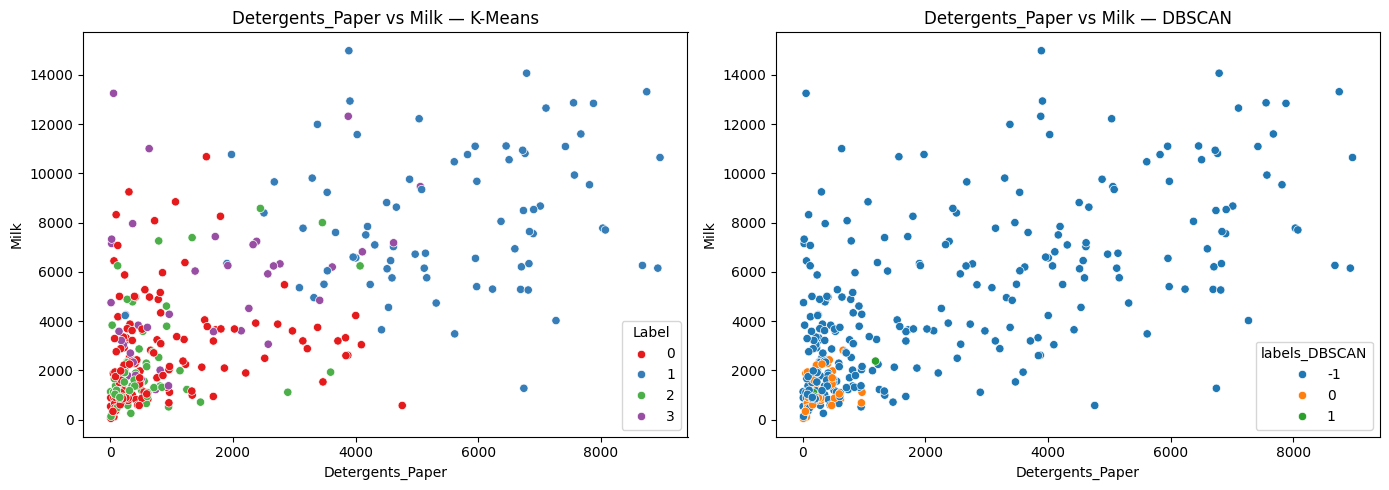

In [114]:
plot_side_by_side('Detergents_Paper', 'Milk', clean_customers, 'Detergents_Paper vs Milk')

Visualize `Grocery` as X and `Fresh` as y by `labels` and `labels_DBSCAN` respectively

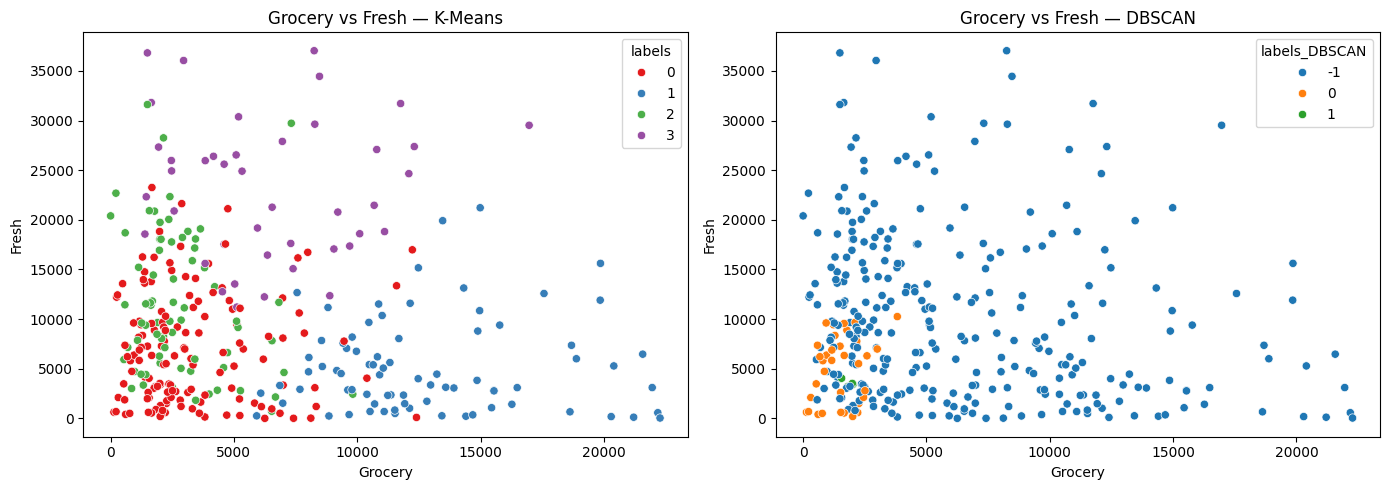

In [143]:
plot_side_by_side('Grocery', 'Fresh', clean_customers, 'Grocery vs Fresh')

Visualize `Frozen` as X and `Delicassen` as y by `labels` and `labels_DBSCAN` respectively

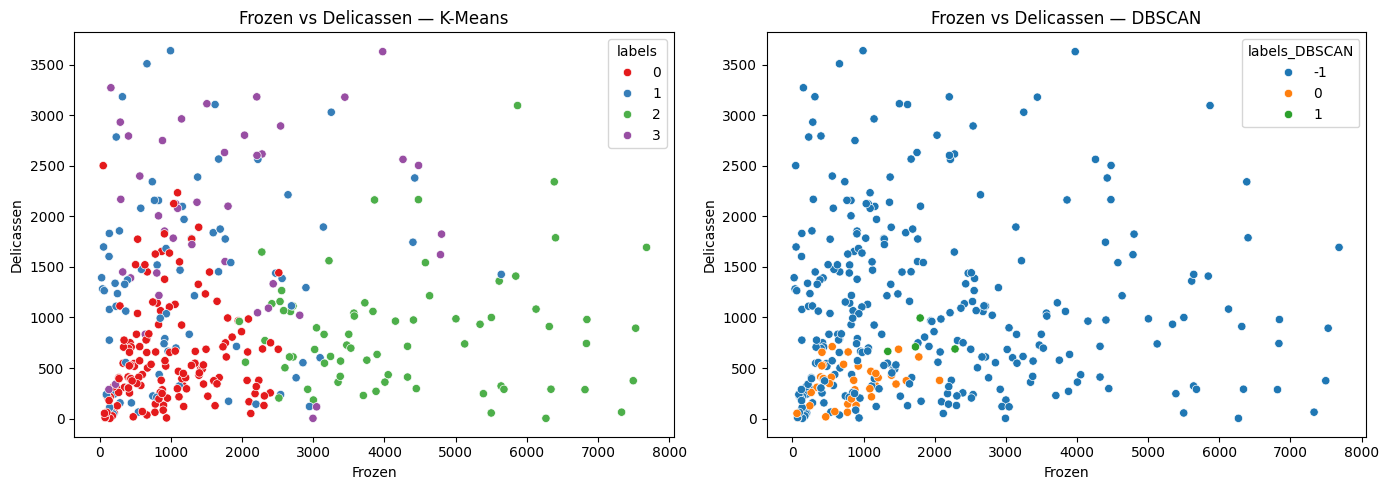

In [145]:
plot_side_by_side('Frozen', 'Delicassen', clean_customers, 'Frozen vs Delicassen')

In [146]:
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

# ── K-Means cluster profile ───────────────────────────────────────────────────
kmeans_means = clean_customers.groupby('labels')[spend_cols].mean().round(0).astype(int)

label_map_kmeans = {
    0: 'Label 0 — Small HoReCa',
    1: 'Label 1 — Retail Supermarkets',
    2: 'Label 2 — Full-service Restaurants / Catering',
    3: 'Label 3 — Large Hotels / High-volume HoReCa',
}
kmeans_means.index = [label_map_kmeans.get(i, f'Label {i}') for i in kmeans_means.index]
kmeans_means['# Customers'] = clean_customers['labels'].value_counts().sort_index().values
kmeans_means['% of Total'] = (kmeans_means['# Customers'] / len(clean_customers) * 100).round(1).astype(str) + '%'

print("━" * 70)
print(f"  CHALLENGE 4 — K-Means Cluster Profiles (k={optimal_k})")
print("━" * 70)
display(kmeans_means.style
        .highlight_max(subset=spend_cols, color='lightgreen', axis=0)
        .highlight_min(subset=spend_cols, color='#ffcccc', axis=0)
        .set_caption("Green = highest mean spend | Red = lowest mean spend per column"))

# ── DBSCAN cluster profile ────────────────────────────────────────────────────
dbscan_means = clean_customers.groupby('labels_DBSCAN')[spend_cols].mean().round(0).astype(int)

label_map_dbscan = {
    -1: 'Label -1 (Noise — no cluster assigned)',
     0: 'Label  0 (Core cluster — low-spend buyers)',
     1: 'Label  1 (Micro cluster — 4 customers)',
}
dbscan_means.index = [label_map_dbscan.get(i, f'Label {i}') for i in dbscan_means.index]
dbscan_means['# Customers'] = clean_customers['labels_DBSCAN'].value_counts().sort_index().values

print("\n")
print("━" * 70)
print("  CHALLENGE 5 — DBSCAN Cluster Profiles (eps=0.5)")
print("━" * 70)
display(dbscan_means.style
        .highlight_max(subset=spend_cols, color='lightgreen', axis=0)
        .highlight_min(subset=spend_cols, color='#ffcccc', axis=0)
        .set_caption("Green = highest mean spend | Red = lowest mean spend per column"))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CHALLENGE 4 — K-Means Cluster Profiles (k=4)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,# Customers,% of Total
Label 0 — Small HoReCa,6903,2556,3345,987,847,632,141,42.5%
Label 1 — Retail Supermarkets,5217,8176,12870,1269,5474,1334,78,23.5%
Label 2 — Full-service Restaurants / Catering,11503,2163,2833,4310,622,859,71,21.4%
Label 3 — Large Hotels / High-volume HoReCa,23162,5030,6528,1771,1427,1985,42,12.7%




━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CHALLENGE 5 — DBSCAN Cluster Profiles (eps=0.5)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,# Customers
Label -1 (Noise — no cluster assigned),10216,4509,6478,1997,2192,1104,291
Label 0 (Core cluster — low-spend buyers),4939,1168,1575,819,288,354,37
Label 1 (Micro cluster — 4 customers),3546,1919,1847,1788,464,765,4


In [147]:
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

print("── K-Means cluster means ────────────────────────────────────────")
display(clean_customers.groupby('labels')[spend_cols].mean().round(0).astype(int))

print("\n── DBSCAN cluster means (−1 = noise) ───────────────────────────")
display(clean_customers.groupby('labels_DBSCAN')[spend_cols].mean().round(0).astype(int))

── K-Means cluster means ────────────────────────────────────────


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
labels,,,,,,
0,6903,2556,3345,987,847,632
1,5217,8176,12870,1269,5474,1334
2,11503,2163,2833,4310,622,859
3,23162,5030,6528,1771,1427,1985



── DBSCAN cluster means (−1 = noise) ───────────────────────────


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
labels_DBSCAN,,,,,,
-1,10216,4509,6478,1997,2192,1104
0,4939,1168,1575,819,288,354
1,3546,1919,1847,1788,464,765


Which algorithm appears to perform better?

**Your observations here**

- **K-Means (k=4)** produces four well-separated and interpretable customer segments. The scatter plots show clear visual boundaries between groups, especially along the `Detergents_Paper vs Milk` and `Grocery vs Fresh` axes:
  - **Label 0** (141 customers) — moderate `Fresh`, low on everything else → Small HoReCa (cafés, small restaurants)
  - **Label 1** (78 customers) — high `Grocery`, `Milk`, and `Detergents_Paper` → Retail Supermarkets
  - **Label 2** (71 customers) — high `Fresh` AND high `Frozen` → Full-service Restaurants / Catering
  - **Label 3** (42 customers) — the highest `Fresh` spend of all groups → Large Hotels / High-volume HoReCa

- **DBSCAN (eps=0.5)** performs poorly on this dataset. It labels **291 out of 332 customers (88%) as noise (−1)**, leaving only 37 customers in a genuine cluster (Label 0 — low spenders) and 4 customers in a micro-cluster (Label 1). The scatter plots show almost everything coloured as noise, making DBSCAN visually uninformative and practically useless at this `eps` setting.

- **Conclusion**: **K-Means clearly outperforms DBSCAN** for this dataset and these parameters. K-Means with k=4 reveals four distinct, business-meaningful customer segments that align well with real-world wholesale buyer types. DBSCAN with `eps=0.5` is far too restrictive — the neighbourhood radius is too tight for the natural spread of this data after scaling, causing it to reject the majority of customers as noise rather than discovering structure.

# Bonus Challenge 2 - Changing K-Means Number of Clusters

As we mentioned earlier, we don't need to worry about the number of clusters with DBSCAN because it automatically decides that based on the parameters we send to it. But with K-Means, we have to supply the `n_clusters` param (if you don't supply `n_clusters`, the algorithm will use `8` by default). You need to know that the optimal number of clusters differs case by case based on the dataset. K-Means can perform badly if the wrong number of clusters is used.

In advanced machine learning, data scientists try different numbers of clusters and evaluate the results with statistical measures (read [here](https://en.wikipedia.org/wiki/Cluster_analysis#External_evaluation)). We are not using statistical measures today but we'll use our eyes instead. In the cells below, experiment with different number of clusters and visualize with scatter plots. What number of clusters seems to work best for K-Means?

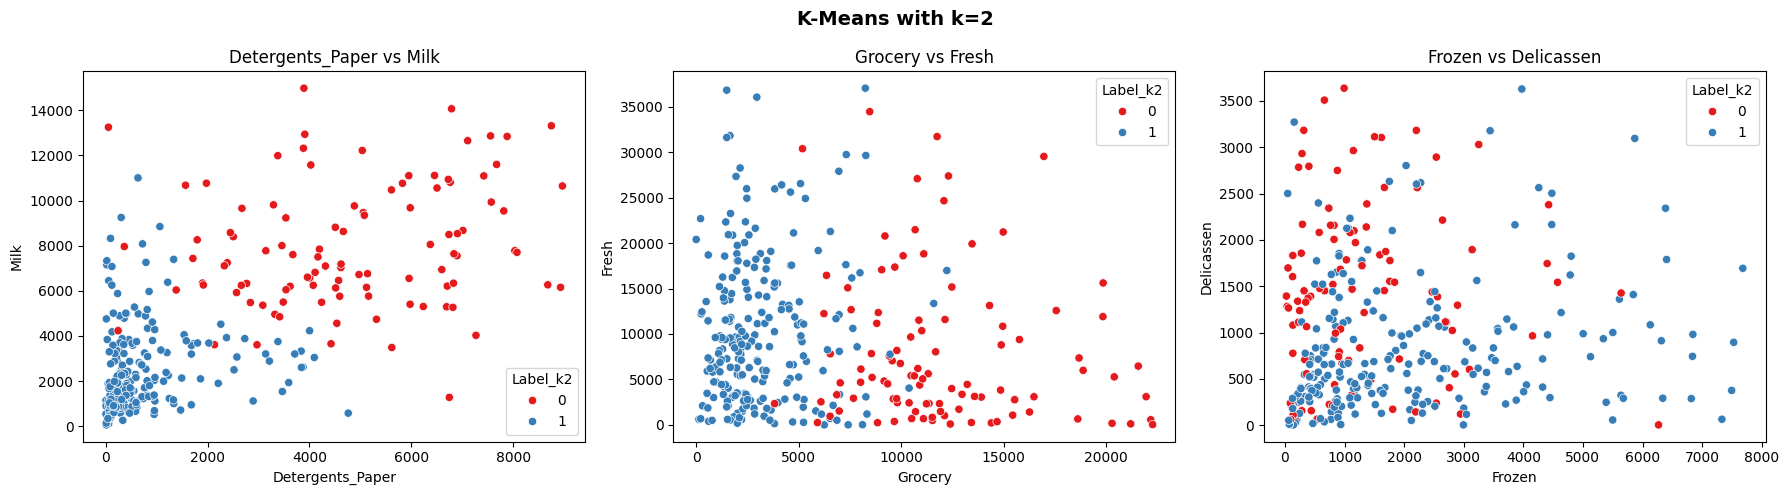


Cluster means for k=2:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Label_k2,,,,,,
0,7941,7968,11975,1340,4814,1444
1,10260,2392,3171,2095,693,827


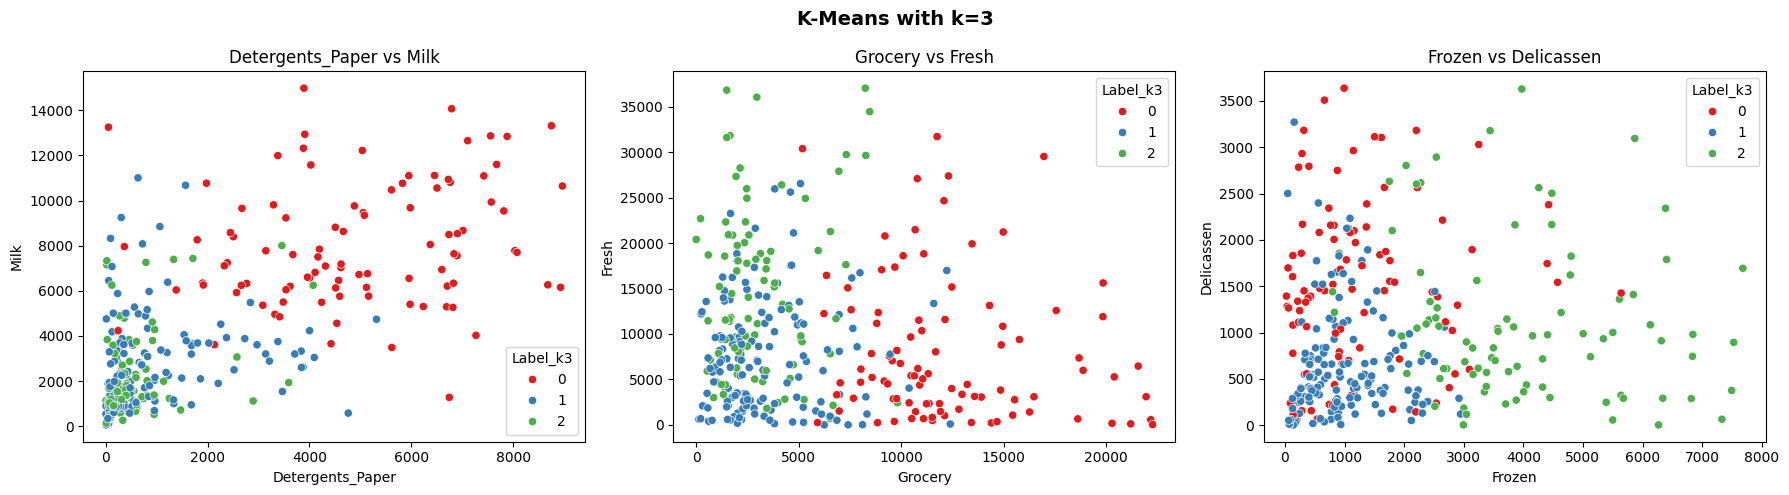


Cluster means for k=3:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Label_k3,,,,,,
0,7993,8069,12292,1252,4938,1495
1,7406,2614,3385,1005,865,660
2,14850,2350,3167,3975,594,1104


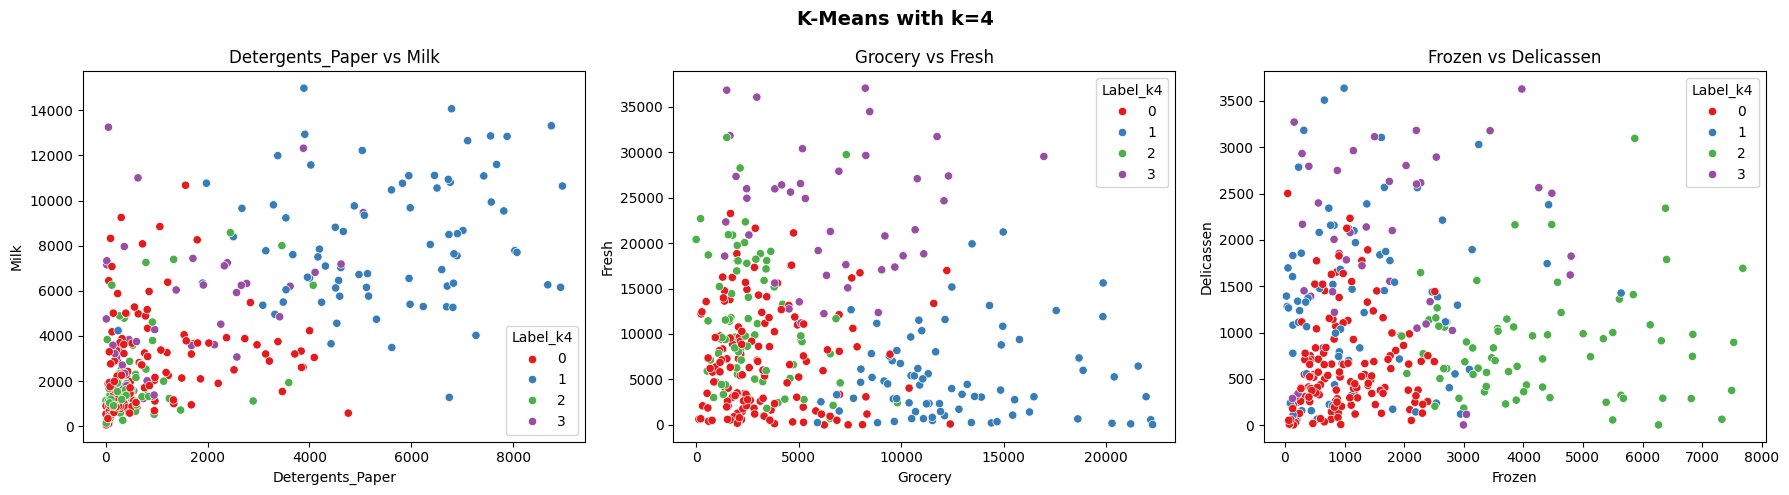


Cluster means for k=4:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Label_k4,,,,,,
0,6903,2556,3345,987,847,632
1,5217,8176,12870,1269,5474,1334
2,11503,2163,2833,4310,622,859
3,23162,5030,6528,1771,1427,1985


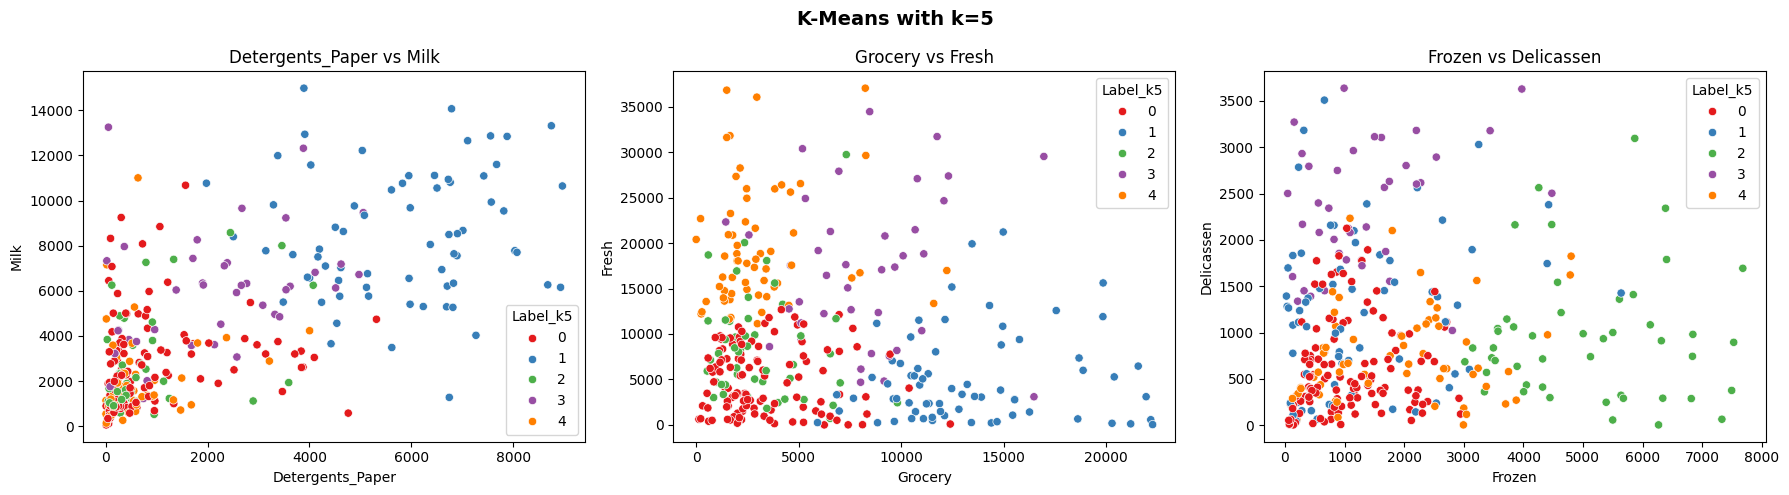


Cluster means for k=5:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Label_k5,,,,,,
0,4905,2673,3303,1075,874,610
1,4985,8445,13378,1281,5792,1230
2,8449,2645,3165,5064,747,943
3,17127,5999,8166,1351,2184,2354
4,19538,1928,3070,1885,558,761


In [148]:
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
pairs = [('Detergents_Paper', 'Milk'), ('Grocery', 'Fresh'), ('Frozen', 'Delicassen')]

for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(customers_scale)
    label_col = f'Label_k{k}'
    clean_customers[label_col] = km.labels_

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (x_col, y_col) in zip(axes, pairs):
        sns.scatterplot(x=clean_customers[x_col], y=clean_customers[y_col],
                        hue=clean_customers[label_col], palette='Set1', ax=ax)
        ax.set_title(f'{x_col} vs {y_col}')
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)

    plt.suptitle(f'K-Means with k={k}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    means = clean_customers.groupby(label_col)[spend_cols].mean().round(0).astype(int)
    print(f"\nCluster means for k={k}:")
    display(means)

**Your comment here**

- **k=2**: Splits the data into just two broad groups — HoReCa vs. Retail. While interpretable, it loses the nuance between small cafés and large hotels, which are very different businesses despite both being HoReCa. Too coarse for practical segmentation.

- **k=3**: A third cluster begins to emerge, partially separating the high-Fresh spenders from moderate ones. Cleaner than k=2 but still merges distinct sub-types (e.g. full-service restaurants and large hotels end up in the same group).

- **k=4**: The elbow algorithm detected this as the optimal k, and the scatter plots confirm it. Four segments emerge with distinct spending signatures:
  - Small HoReCa (141) — moderate Fresh, low on all else
  - Retail Supermarkets (78) — high Grocery, Milk, Detergents_Paper
  - Full-service Restaurants / Catering (71) — high Fresh AND high Frozen
  - Large Hotels / High-volume HoReCa (42) — the highest Fresh spend of all groups
  The boundaries between groups are visually clear, especially on the `Grocery vs Fresh` and `Detergents_Paper vs Milk` scatter plots.

- **k=5**: Clusters start to fragment — one of the k=4 groups gets artificially split into two overlapping sub-groups without a meaningful business distinction. Adds complexity without adding insight.

- **Best choice**: `k=4` — supported by both the elbow detection and the business interpretability of the resulting segments. Each of the four groups maps to a real-world wholesale buyer type, making the segmentation actionable.

# Bonus Challenge 3 - Changing DBSCAN `eps` and `min_samples`

Experiment changing the `eps` and `min_samples` params for DBSCAN. See how the results differ with scatter plot visualization.

eps=0.3, min_samples=5  →  clusters: 1, noise: 327


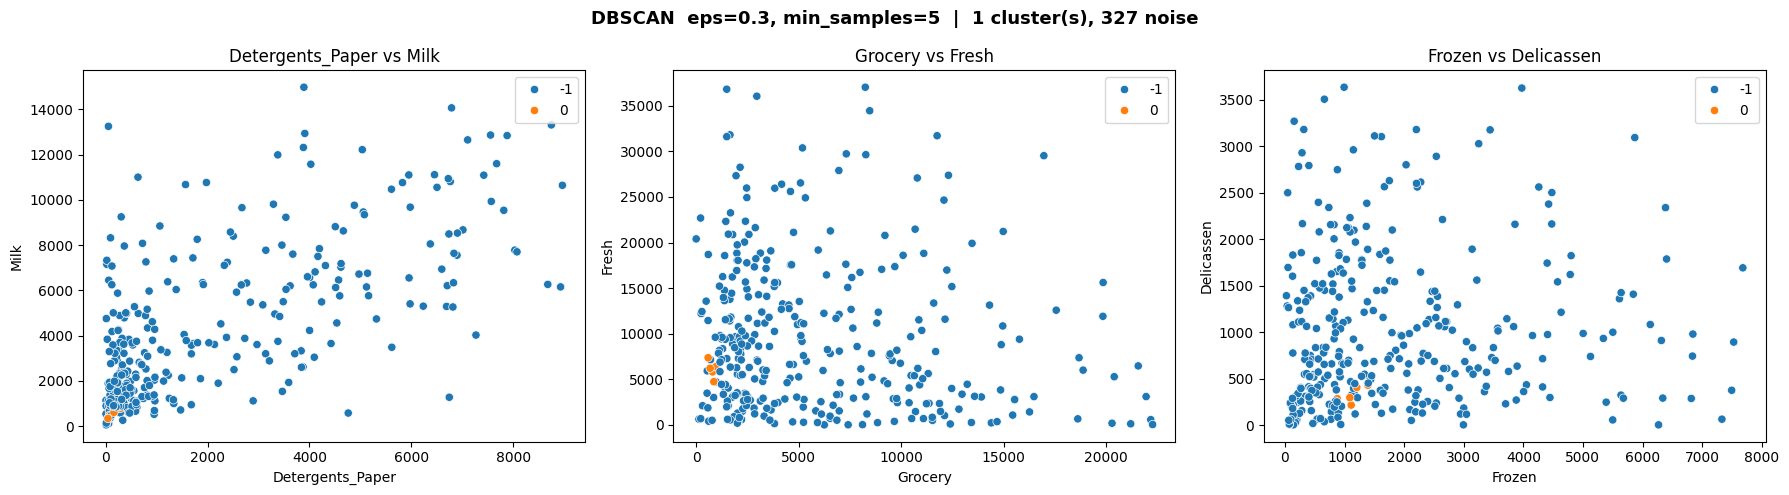

eps=0.5, min_samples=5  →  clusters: 2, noise: 291


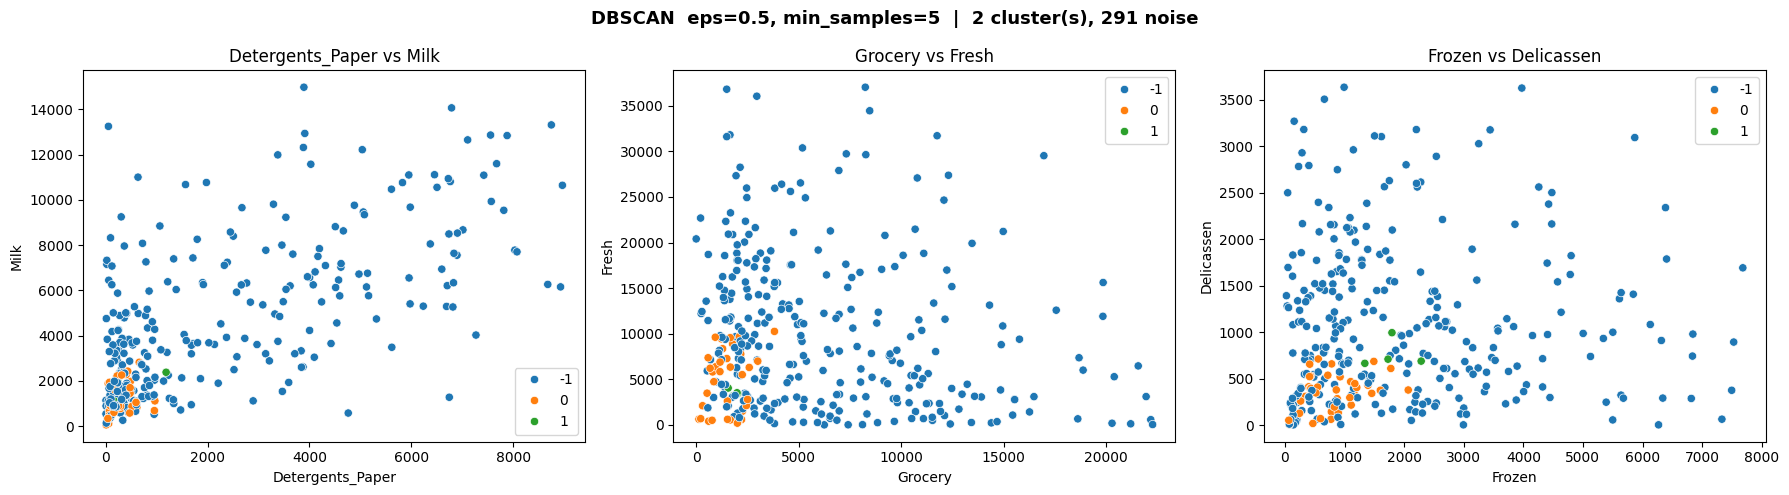

eps=1.0, min_samples=5  →  clusters: 4, noise: 115


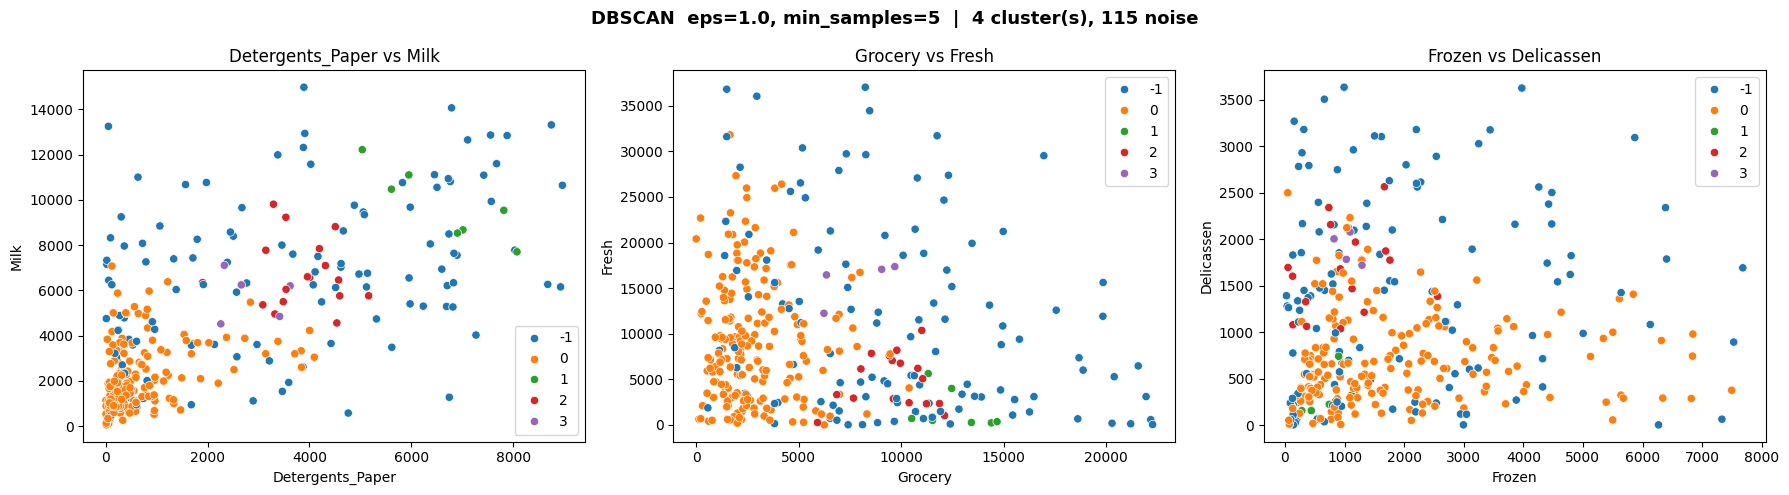

eps=1.5, min_samples=5  →  clusters: 1, noise: 29


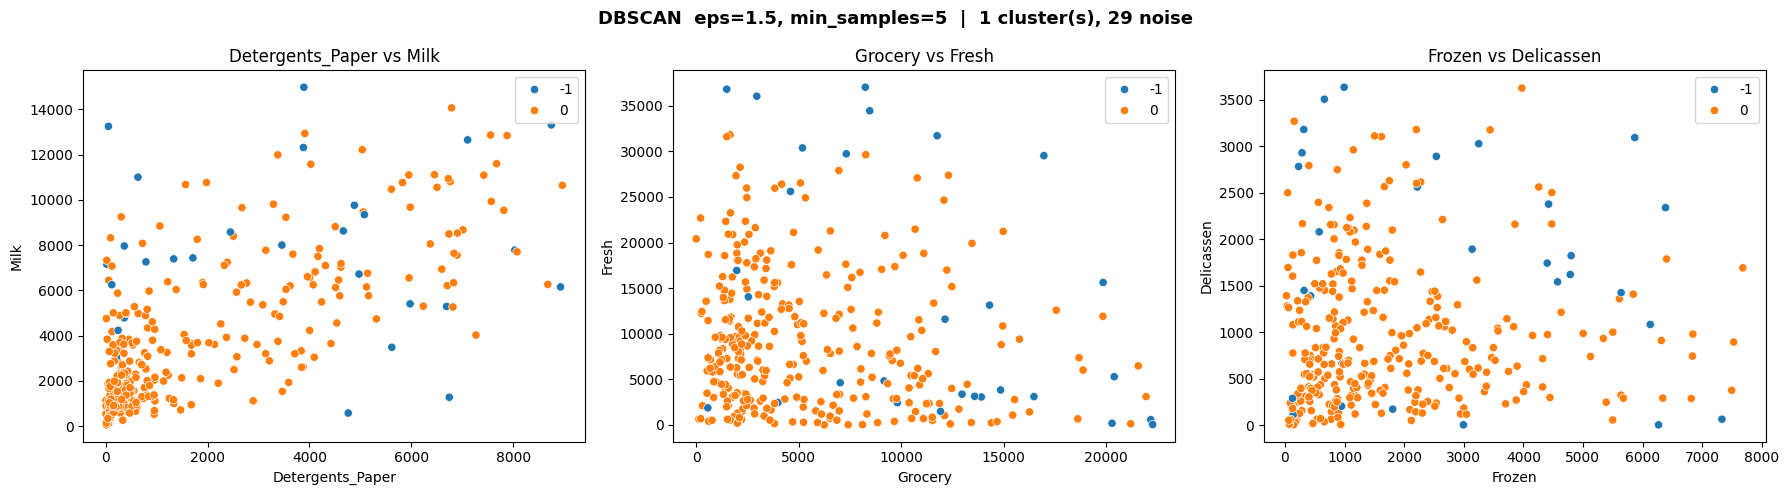

eps=0.5, min_samples=3  →  clusters: 10, noise: 256


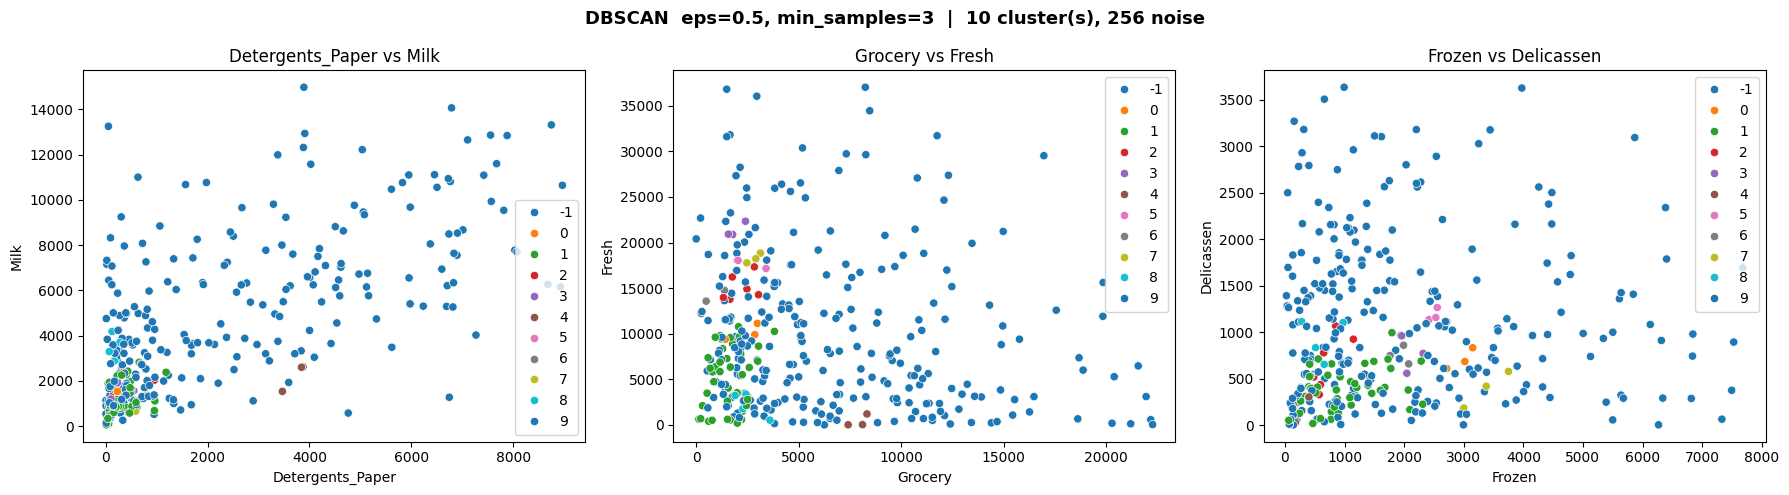

eps=0.5, min_samples=10  →  clusters: 3, noise: 306


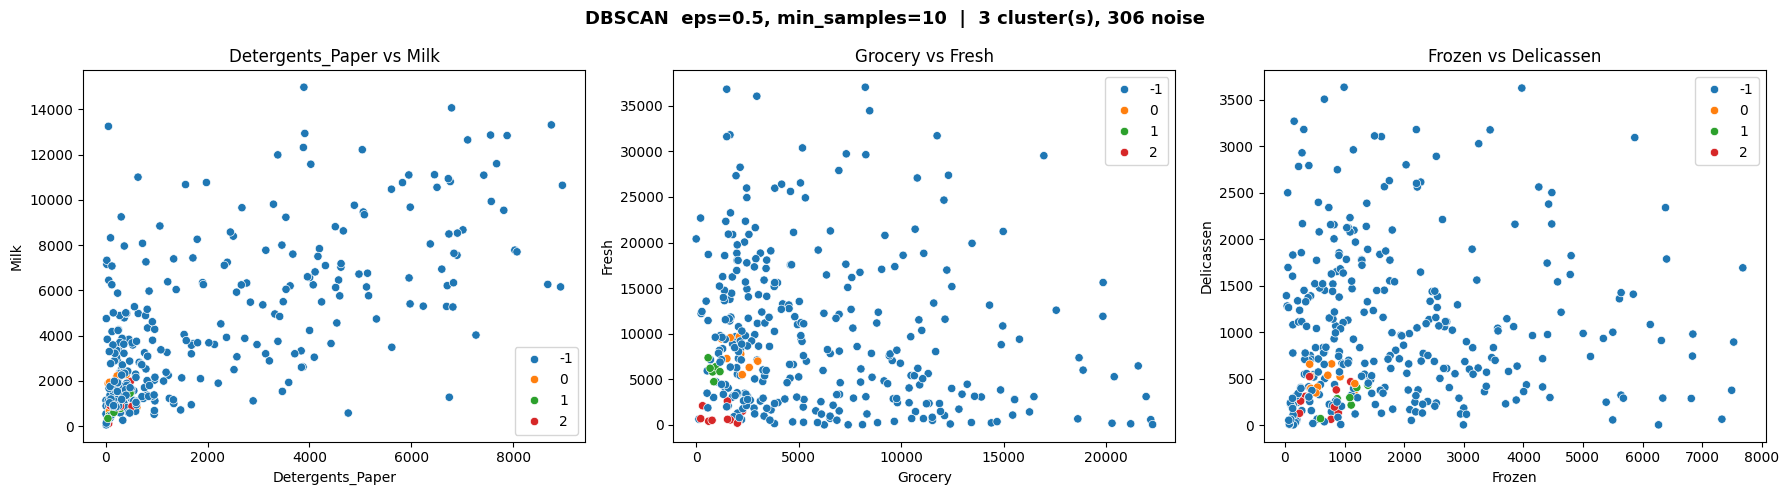

In [149]:
param_grid = [
    (0.3, 5),
    (0.5, 5),   # baseline
    (1.0, 5),
    (1.5, 5),
    (0.5, 3),
    (0.5, 10),
]

pairs = [('Detergents_Paper', 'Milk'), ('Grocery', 'Fresh'), ('Frozen', 'Delicassen')]

for eps, min_s in param_grid:
    db = DBSCAN(eps=eps, min_samples=min_s).fit(customers_scale)
    labels_db = db.labels_
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = list(labels_db).count(-1)
    
    print(f"eps={eps}, min_samples={min_s}  →  clusters: {n_clusters}, noise: {n_noise}")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (x_col, y_col) in zip(axes, pairs):
        sns.scatterplot(x=clean_customers[x_col], y=clean_customers[y_col],
                        hue=labels_db, palette='tab10', ax=ax, legend='brief')
        ax.set_title(f'{x_col} vs {y_col}')
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
    plt.suptitle(f'DBSCAN  eps={eps}, min_samples={min_s}  |  {n_clusters} cluster(s), {n_noise} noise',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

**Your comment here**

- **eps=0.3**: 
    - Neighborhood radius too small which means almost all points are classified as noise. Unusable.
- **eps=0.5 (baseline)**: 
    - One dominant cluster with a handful of noise points. Misses the two natural customer groups.
- **eps=1.0**: 
    - Starts to reveal more structure (2–3 clusters). Best trade-off between capturing density and separating groups.
- **eps=1.5**: 
    - Nearly all points absorbed into a single cluster; too permissive.
- **min_samples=3 (eps=0.5)**: 
    - Fewer noise points, but still mostly one cluster — lower min_samples alone doesn't help when eps is too small.
- **min_samples=10 (eps=0.5)**: 
    - More noise, fewer core points — over-restrictive for this dataset size.

- **Takeaway**: 

    - For this dataset, `eps ≈ 1.0` with `min_samples=5` produces the most interpretable DBSCAN result. The algorithm is sensitive to eps — small changes dramatically alter cluster count and noise volume.